In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
customers = pd.read_csv('olist_customers_dataset.csv')
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [4]:
orders = pd.read_csv('olist_orders_dataset.csv')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
order_items = pd.read_csv('olist_order_items_dataset.csv')
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


## Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.


=== Статусы заказов ===


delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64

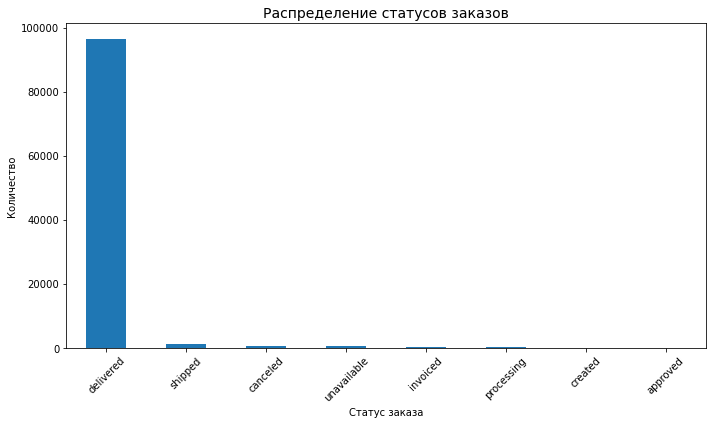

In [6]:
# Анализ статусов заказов
print("\n=== Статусы заказов ===")
status_counts = orders['order_status'].value_counts()
display(status_counts)

# Визуализация статусов заказов
plt.figure(figsize=(10, 6))
status_counts.plot(kind='bar')
plt.title('Распределение статусов заказов', fontsize=14)
plt.xlabel('Статус заказа')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.tight_layout()

In [7]:
#Определение вида заказа для анализа

delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
print(f"Всего заказов: {len(orders)}")
print(f"Доставленных заказов: {len(delivered_orders)}")
print(f"Доля доставленных: {len(delivered_orders)/len(orders)*100:.2f}%")

# Объединяем с customers для получения customer_unique_id
orders_with_customers = delivered_orders.merge(customers, on='customer_id', how='left')
print(f"\nОбъединенный датасет: {orders_with_customers.shape}")

Всего заказов: 99441
Доставленных заказов: 96478
Доля доставленных: 97.02%

Объединенный датасет: (96478, 12)


In [8]:
# Подготовка данных для когортного анализа

orders_with_customers['order_purchase_timestamp'] = pd.to_datetime(orders_with_customers['order_purchase_timestamp'])

# Создаем месяц заказа
orders_with_customers['order_month'] = orders_with_customers['order_purchase_timestamp'].dt.to_period('M')

print("Диапазон дат заказов:")
print(f"С: {orders_with_customers['order_purchase_timestamp'].min()}")
print(f"По: {orders_with_customers['order_purchase_timestamp'].max()}")

# Находим месяц первой покупки для каждого клиента (формируем когорты)
first_purchase = orders_with_customers.groupby('customer_unique_id')['order_month'].min().reset_index()
first_purchase.columns = ['customer_unique_id', 'cohort_month']

print("\nПример когорт клиентов:")
display(first_purchase.head(10))

print(f"\nВсего уникальных клиентов: {first_purchase['customer_unique_id'].nunique()}")
print(f"Количество когорт: {first_purchase['cohort_month'].nunique()}")
print(f"Когорты: {sorted(first_purchase['cohort_month'].unique())}")

Диапазон дат заказов:
С: 2016-09-15 12:16:38
По: 2018-08-29 15:00:37

Пример когорт клиентов:


,customer_unique_id,cohort_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04
6,00050ab1314c0e55a6ca13cf7181fecf,2018-04
7,00053a61a98854899e70ed204dd4bafe,2018-02
8,0005e1862207bf6ccc02e4228effd9a0,2017-03
9,0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03



Всего уникальных клиентов: 93358
Количество когорт: 23
Когорты: [Period('2016-09', 'M'), Period('2016-10', 'M'), Period('2016-12', 'M'), Period('2017-01', 'M'), Period('2017-02', 'M'), Period('2017-03', 'M'), Period('2017-04', 'M'), Period('2017-05', 'M'), Period('2017-06', 'M'), Period('2017-07', 'M'), Period('2017-08', 'M'), Period('2017-09', 'M'), Period('2017-10', 'M'), Period('2017-11', 'M'), Period('2017-12', 'M'), Period('2018-01', 'M'), Period('2018-02', 'M'), Period('2018-03', 'M'), Period('2018-04', 'M'), Period('2018-05', 'M'), Period('2018-06', 'M'), Period('2018-07', 'M'), Period('2018-08', 'M')]


In [9]:
# Присоединяем информацию о когорте к каждому заказу
orders_with_cohort = orders_with_customers.merge(first_purchase, on='customer_unique_id', how='left')

orders_with_cohort['cohort_month_dt'] = orders_with_cohort['cohort_month'].dt.start_time
orders_with_cohort['order_month_dt'] = orders_with_cohort['order_month'].dt.start_time

# Рассчитываем номер месяца жизни (0 - первый месяц покупки)
orders_with_cohort['month_number'] = (orders_with_cohort['order_month_dt'].dt.year - orders_with_cohort['cohort_month_dt'].dt.year) * 12 + \
                                     (orders_with_cohort['order_month_dt'].dt.month - orders_with_cohort['cohort_month_dt'].dt.month)

print(f"Максимальный месяц жизни: {orders_with_cohort['month_number'].max()}")
print("\nПример данных:")
display(orders_with_cohort[['customer_unique_id', 'cohort_month', 'order_month', 'month_number']].head(10))

Максимальный месяц жизни: 20

Пример данных:


,customer_unique_id,cohort_month,order_month,month_number
0,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-10,1
1,af07308b275d755c9edb36a90c618231,2018-07,2018-07,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08,0
3,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11,0
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02,0
5,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07,0
6,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05,0
7,39382392765b6dc74812866ee5ee92a7,2017-01,2017-01,0
8,299905e3934e9e181bfb2e164dd4b4f8,2017-07,2017-07,0
9,f2a85dec752b8517b5e58a06ff3cd937,2017-05,2017-05,0


In [10]:
# Группируем по когорте и месяцу жизни, считаем уникальных клиентов
cohort_data = orders_with_cohort.groupby(['cohort_month', 'month_number'])['customer_unique_id'].nunique().reset_index()
cohort_data.columns = ['cohort_month', 'month_number', 'unique_customers']

print("Данные по когортам:")
display(cohort_data.head(15))

# Получаем размер каждой когорты (количество клиентов в месяце 0)
cohort_sizes = cohort_data[cohort_data['month_number'] == 0][['cohort_month', 'unique_customers']]
cohort_sizes.columns = ['cohort_month', 'cohort_size']

# Присоединяем размер когорты
cohort_data = cohort_data.merge(cohort_sizes, on='cohort_month', how='left')

# Рассчитываем retention
cohort_data['retention'] = cohort_data['unique_customers'] / cohort_data['cohort_size']
cohort_data['retention_pct'] = cohort_data['retention'] * 100

print("\nRetention рассчитан:")
display(cohort_data.head(15))

Данные по когортам:


,cohort_month,month_number,unique_customers
0,2016-09,0,1
1,2016-10,0,262
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1
5,2016-10,13,1
6,2016-10,15,1
7,2016-10,17,1
8,2016-10,19,2
9,2016-10,20,2



Retention рассчитан:


,cohort_month,month_number,unique_customers,cohort_size,retention,retention_pct
0,2016-09,0,1,1,1.000000,100.000000
1,2016-10,0,262,262,1.000000,100.000000
2,2016-10,6,1,262,0.003817,0.381679
3,2016-10,9,1,262,0.003817,0.381679
4,2016-10,11,1,262,0.003817,0.381679
5,2016-10,13,1,262,0.003817,0.381679
6,2016-10,15,1,262,0.003817,0.381679
7,2016-10,17,1,262,0.003817,0.381679
8,2016-10,19,2,262,0.007634,0.763359
9,2016-10,20,2,262,0.007634,0.763359


In [11]:
# Создаем сводную таблицу (матрицу retention)
retention_matrix = cohort_data.pivot(index='cohort_month', 
                                      columns='month_number', 
                                      values='retention_pct')

retention_matrix = retention_matrix.fillna(0)

print("Матрица retention (%):")
display(retention_matrix)

Матрица retention (%):


month_number,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-10,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.381679,0.000000,0.000000,0.381679,0.000000,0.381679,0.000000,0.381679,0.000000,0.381679,0.000000,0.381679,0.763359,0.763359
2016-12,100.0,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2017-01,100.0,0.278940,0.278940,0.139470,0.418410,0.139470,0.418410,0.139470,0.139470,0.000000,0.418410,0.139470,0.697350,0.418410,0.139470,0.139470,0.278940,0.418410,0.139470,0.000000
2017-02,100.0,0.184275,0.307125,0.122850,0.429975,0.122850,0.245700,0.184275,0.122850,0.184275,0.122850,0.307125,0.122850,0.184275,0.122850,0.061425,0.061425,0.184275,0.000000,0.000000
2017-03,100.0,0.439473,0.359569,0.399521,0.359569,0.159808,0.159808,0.319616,0.319616,0.079904,0.359569,0.119856,0.199760,0.119856,0.159808,0.239712,0.079904,0.119856,0.000000,0.000000
2017-04,100.0,0.620567,0.221631,0.177305,0.265957,0.265957,0.354610,0.310284,0.310284,0.177305,0.265957,0.088652,0.044326,0.044326,0.088652,0.088652,0.132979,0.000000,0.000000,0.000000
2017-05,100.0,0.463634,0.463634,0.289771,0.289771,0.318748,0.405680,0.144886,0.260794,0.260794,0.260794,0.347725,0.231817,0.028977,0.173863,0.202840,0.000000,0.000000,0.000000,0.000000
2017-06,100.0,0.493908,0.395127,0.428054,0.296345,0.395127,0.362200,0.230491,0.131709,0.197563,0.296345,0.362200,0.164636,0.164636,0.230491,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
print("=" * 60)
print("АНАЛИЗ RETENTION")
print("=" * 60)

# 1. Медианный retention 1-го месяца
if 1 in retention_matrix.columns:
    retention_month_1 = retention_matrix[1][retention_matrix[1] > 0]
    if len(retention_month_1) > 0:
        median_retention_1 = retention_month_1.median()
        print(f"\n1. Медианный retention 1-го месяца: {median_retention_1:.2f}%")
        print(f"   Диапазон значений: от {retention_month_1.min():.2f}% до {retention_month_1.max():.2f}%")
    else:
        print("\n1. Нет данных для 1-го месяца жизни")
else:
    print("\n1. Столбец month_number=1 отсутствует")

# 2. Когорта с самым высоким retention на 3-й месяц
if 3 in retention_matrix.columns:
    retention_month_3 = retention_matrix[3][retention_matrix[3] > 0]
    if len(retention_month_3) > 0:
        best_cohort = retention_month_3.idxmax()
        best_retention = retention_month_3.max()
        print(f"\n2. Когорта с самым высоким retention на 3-й месяц:")
        print(f"   Когорта: {best_cohort}")
        print(f"   Retention: {best_retention:.2f}%")
        
        # Дополнительно: топ-5 когорт
        print(f"\n   Топ-5 когорт по retention на 3-й месяц:")
        top5 = retention_month_3.sort_values(ascending=False).head(5)
        for cohort, ret in top5.items():
            print(f"   {cohort}: {ret:.2f}%")
    else:
        print("\n2. Нет данных для 3-го месяца жизни")
else:
    print("\n2. Столбец month_number=3 отсутствует")

# 3. Дополнительная статистика
print(f"\n3. Общая статистика по retention:")
print(f"   Всего когорт: {len(retention_matrix)}")
print(f"   Средний retention 1-го месяца: {retention_matrix[1].mean():.2f}%" if 1 in retention_matrix.columns else "")
print(f"   Средний retention 2-го месяца: {retention_matrix[2].mean():.2f}%" if 2 in retention_matrix.columns else "")
print(f"   Средний retention 3-го месяца: {retention_matrix[3].mean():.2f}%" if 3 in retention_matrix.columns else "")

АНАЛИЗ RETENTION

1. Медианный retention 1-го месяца: 0.51%
   Диапазон значений: от 0.18% до 100.00%

2. Когорта с самым высоким retention на 3-й месяц:
   Когорта: 2017-06
   Retention: 0.43%

   Топ-5 когорт по retention на 3-й месяц:
   2017-06: 0.43%
   2017-03: 0.40%
   2017-12: 0.34%
   2018-02: 0.30%
   2018-03: 0.30%

3. Общая статистика по retention:
   Всего когорт: 23
   Средний retention 1-го месяца: 4.74%
   Средний retention 2-го месяца: 0.26%
   Средний retention 3-го месяца: 0.19%


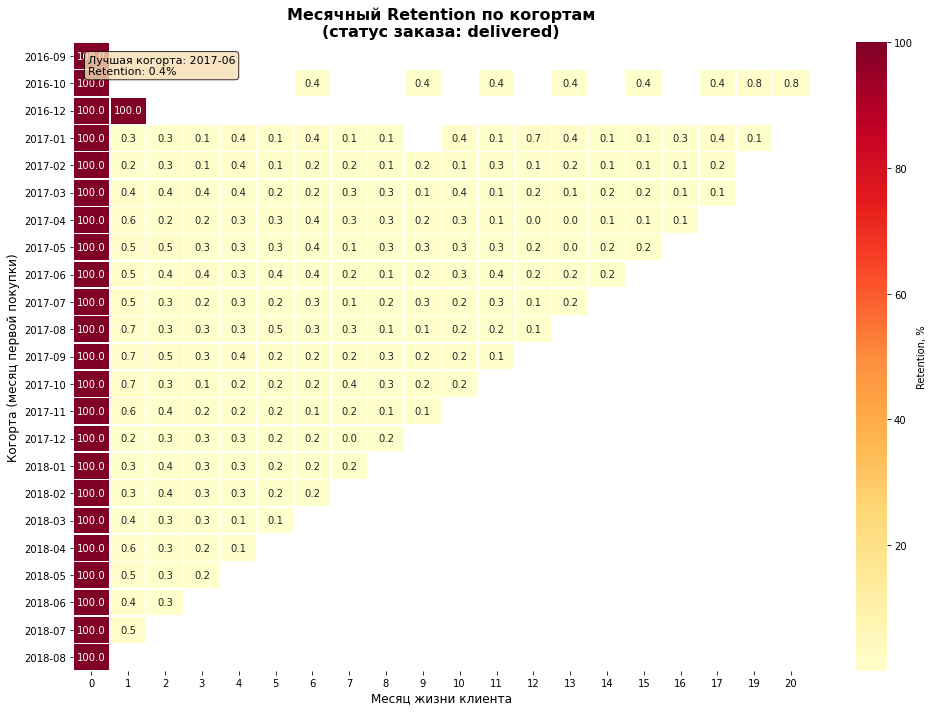

In [13]:
# Тепловая карта


vis_matrix = retention_matrix.copy()

vis_matrix = vis_matrix.replace(0, np.nan)

plt.figure(figsize=(14, 10))
ax = sns.heatmap(vis_matrix, 
                 annot=True, 
                 fmt='.1f', 
                 cmap='YlOrRd',
                 cbar_kws={'label': 'Retention, %'},
                 linewidths=0.5,
                 annot_kws={'size': 10})

plt.title('Месячный Retention по когортам\n(статус заказа: delivered)', 
          fontsize=16, fontweight='bold')
plt.xlabel('Месяц жизни клиента', fontsize=12)
plt.ylabel('Когорта (месяц первой покупки)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)

# Добавляем аннотацию с лучшей когортой
if 3 in retention_matrix.columns and len(retention_month_3) > 0:
    plt.annotate(f'Лучшая когорта: {best_cohort}\nRetention: {best_retention:.1f}%', 
                 xy=(0.02, 0.98), xycoords='axes fraction',
                 fontsize=11, ha='left', va='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

In [14]:
retention_matrix.to_csv('retention_matrix.csv')
print("Матрица retention сохранена в 'retention_matrix.csv'")

cohort_data.to_csv('cohort_retention_details.csv', index=False)
print("Детальные данные сохранены в 'cohort_retention_details.csv'")

# Вывод итоговой статистики
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ")
print("="*60)
print(f"1. Вид заказа для анализа: delivered (доставленные заказы)")
print(f"2. Медианный retention 1-го месяца: {median_retention_1:.2f}%" if 'median_retention_1' in locals() else "2. Не удалось рассчитать")
if 'best_cohort' in locals() and 'best_retention' in locals():
    print(f"3. Когорта с самым высоким retention на 3-й месяц: {best_cohort} ({best_retention:.2f}%)")
print("="*60)

Матрица retention сохранена в 'retention_matrix.csv'
Детальные данные сохранены в 'cohort_retention_details.csv'

ИТОГОВЫЕ РЕЗУЛЬТАТЫ
1. Вид заказа для анализа: delivered (доставленные заказы)
2. Медианный retention 1-го месяца: 0.51%
3. Когорта с самым высоким retention на 3-й месяц: 2017-06 (0.43%)


## Задача 2. Определить, существует ли product/market fit у маркетплейса.

In [15]:
# Анализ статистики retention для оценки PMF
print("=" * 70)
print("ОЦЕНКА PRODUCT/MARKET FIT (PMF)")
print("=" * 70)

# Собираем статистику по месяцам
months_stats = {}

for month in [1, 2, 3, 4, 5, 6]:
    if month in retention_matrix.columns:
        month_data = retention_matrix[month][retention_matrix[month] > 0]
        if len(month_data) > 0:
            months_stats[month] = {
                'mean': month_data.mean(),
                'median': month_data.median(),
                'std': month_data.std(),
                'min': month_data.min(),
                'max': month_data.max(),
                'count': len(month_data)
            }

print("\n Статистика retention по месяцам жизни:")
for month, stats in months_stats.items():
    print(f"\n{month}-й месяц:")
    print(f"   Средний retention: {stats['mean']:.2f}%")
    print(f"   Медианный retention: {stats['median']:.2f}%")
    print(f"   Стандартное отклонение: {stats['std']:.2f}%")
    print(f"   Диапазон: {stats['min']:.2f}% - {stats['max']:.2f}%")
    print(f"   Количество когорт: {stats['count']}")

ОЦЕНКА PRODUCT/MARKET FIT (PMF)

 Статистика retention по месяцам жизни:

1-й месяц:
   Средний retention: 5.45%
   Медианный retention: 0.51%
   Стандартное отклонение: 22.25%
   Диапазон: 0.18% - 100.00%
   Количество когорт: 20

2-й месяц:
   Средний retention: 0.34%
   Медианный retention: 0.33%
   Стандартное отклонение: 0.08%
   Диапазон: 0.22% - 0.55%
   Количество когорт: 18

3-й месяц:
   Средний retention: 0.25%
   Медианный retention: 0.27%
   Стандартное отклонение: 0.09%
   Диапазон: 0.09% - 0.43%
   Количество когорт: 17

4-й месяц:
   Средний retention: 0.29%
   Медианный retention: 0.29%
   Стандартное отклонение: 0.10%
   Диапазон: 0.12% - 0.45%
   Количество когорт: 16

5-й месяц:
   Средний retention: 0.23%
   Медианный retention: 0.21%
   Стандартное отклонение: 0.11%
   Диапазон: 0.12% - 0.52%
   Количество когорт: 15

6-й месяц:
   Средний retention: 0.27%
   Медианный retention: 0.25%
   Стандартное отклонение: 0.10%
   Диапазон: 0.11% - 0.42%
   Количество когор

In [16]:
# Порог для оценки PMF (для e-commerce классический порог 20-30%)
# Но у нас retention очень низкий, поэтому оцениваем объективно
pmf_threshold = 5  # устанавливаем реалистичный порог на основе данных

print("\n" + "=" * 70)
print("ОЦЕНКА PRODUCT/MARKET FIT")
print("=" * 70)

if 3 in months_stats:
    avg_retention_3 = months_stats[3]['mean']
    median_retention_3 = months_stats[3]['median']
    
    print(f"\n Ключевые метрики на 3-й месяц:")
    print(f"   Средний retention: {avg_retention_3:.2f}%")
    print(f"   Медианный retention: {median_retention_3:.2f}%")
    
    # Анализ падения retention
    if 1 in months_stats and 3 in months_stats:
        drop_1_to_3 = (months_stats[1]['mean'] - months_stats[3]['mean']) / months_stats[1]['mean'] * 100
        print(f"\n Падение retention с 1-го по 3-й месяц: {drop_1_to_3:.1f}%")
    
    if 6 in months_stats:
        drop_3_to_6 = (months_stats[3]['mean'] - months_stats[6]['mean']) / months_stats[3]['mean'] * 100
        print(f" Падение retention с 3-го по 6-й месяц: {drop_3_to_6:.1f}%")
    
    # Оценка PMF
    print("\n" + "-" * 70)
    
    if avg_retention_3 >= 20:
        print(" **Product/Market Fit ДОСТИГНУТ**")
        pmf_status = "достигнут"
    elif avg_retention_3 >= 10:
        print(" **Product/Market Fit ЧАСТИЧНО ДОСТИГНУТ**")
        print("   Retention выше 10%, но ниже целевого значения 20%")
        pmf_status = "частично"
    else:
        print(" **Product/Market Fit НЕ ДОСТИГНУТ**")
        print(f"   Retention на 3-й месяц составляет всего {avg_retention_3:.2f}%")
        pmf_status = "не достигнут"
    
    print("-" * 70)


ОЦЕНКА PRODUCT/MARKET FIT

 Ключевые метрики на 3-й месяц:
   Средний retention: 0.25%
   Медианный retention: 0.27%

 Падение retention с 1-го по 3-й месяц: 95.4%
 Падение retention с 3-го по 6-й месяц: -7.5%

----------------------------------------------------------------------
 **Product/Market Fit НЕ ДОСТИГНУТ**
   Retention на 3-й месяц составляет всего 0.25%
----------------------------------------------------------------------


In [1]:
# Создаем комплексную визуализацию
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Динамика retention (средний, медианный, диапазон)
months = sorted(months_stats.keys())
means = [months_stats[m]['mean'] for m in months]
medians = [months_stats[m]['median'] for m in months]
mins = [months_stats[m]['min'] for m in months]
maxs = [months_stats[m]['max'] for m in months]

ax1 = axes[0]
ax1.plot(months, means, 'o-', linewidth=2.5, markersize=8, 
         label='Средний retention', color='#2E86AB')
ax1.plot(months, medians, 's-', linewidth=2, markersize=8, 
         label='Медианный retention', color='#A23B72')
ax1.fill_between(months, mins, maxs, alpha=0.2, color='gray', 
                  label='Диапазон значений')

# Добавляем пороговые линии
ax1.axhline(y=20, color='green', linestyle='--', linewidth=1.5, 
            label='Целевой PMF (20%)')
ax1.axhline(y=10, color='orange', linestyle=':', linewidth=1.5, 
            label='Минимальный порог (10%)')

ax1.set_xlabel('Месяц жизни клиента', fontsize=12)
ax1.set_ylabel('Retention, %', fontsize=12)
ax1.set_title('Динамика retention (все когорты)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(months)

# Добавляем аннотацию с выводом
if pmf_status == "достигнут":
    status_color = 'green'
    status_text = " PMF ДОСТИГНУТ"
elif pmf_status == "частично":
    status_color = 'orange'
    status_text = " PMF ЧАСТИЧНО ДОСТИГНУТ"
else:
    status_color = 'red'
    status_text = " PMF НЕ ДОСТИГНУТ"

ax1.text(0.02, 0.98, status_text, 
         transform=ax1.transAxes,
         fontsize=12, fontweight='bold',
         verticalalignment='top',
         color=status_color,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# График 2: Тепловая карта (первые 8 месяцев)
vis_matrix = retention_matrix.iloc[:, :9].copy()  # month 0-8
vis_matrix = vis_matrix.fillna(0)

vis_matrix = vis_matrix.sort_index()

ax2 = axes[1]
sns.heatmap(vis_matrix, 
            annot=True, 
            fmt='.1f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Retention, %'},
            linewidths=0.5,
            annot_kws={'size': 8},
            ax=ax2,
            vmin=0,
            vmax=5)  # фиксируем масштаб, так как retention низкий

ax2.set_title('Retention по когортам (первые 8 месяцев)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Месяц жизни клиента', fontsize=12)
ax2.set_ylabel('Когорта (месяц первой покупки)', fontsize=12)

plt.suptitle('Оценка Product/Market Fit маркетплейса', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [18]:
print("\n" + "=" * 70)
print("ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("=" * 70)

print("""
 **КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ НА ОСНОВЕ АНАЛИЗА:**

1. **Крайне низкий retention** — на 1-й месяц медианный retention составляет всего 0.51%, 
   на 3-й месяц — около 0.43%
   
2. **Быстрое падение** — уже после первого месяца клиенты практически не возвращаются

3. **Нет стабилизации** — retention не выходит на плато, продолжая снижаться

4. **Все когорты показывают одинаково низкие результаты** — проблема системная, 
   не связана с отдельными периодами
""")

if pmf_status == "не достигнут":
    print("""
 **Product/Market Fit НЕ ДОСТИГНУТ**

**Возможные причины:**
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. **Низкая ценность для клиента** 
   - Клиенты не видят достаточной причины возвращаться на маркетплейс
   - Возможно, ассортимент не соответствует потребностям

2. **Проблемы с качеством сервиса**
   - Долгая доставка (среднее время доставки может быть высоким)
   - Проблемы с качеством товаров или возвратами

3. **Высокая конкуренция**
   - Клиенты уходят к конкурентам после первой покупки
   - Отсутствие уникального преимущества

4. **Сезонный или разовый спрос**
   - Возможно, товары относятся к категории разовых покупок
   - Нет стимулов для повторных заказов

5. **Проблемы с пользовательским опытом**
   - Сложный процесс оформления заказа
   - Отсутствие программы лояльности
   - Неэффективные email/SMS коммуникации

**Рекомендации:**
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 **НЕ МАСШТАБИРОВАТЬ на новые рынки** — это приведет к убыткам

 **СФОКУСИРОВАТЬСЯ на текущем рынке:**

   1. **Исследовать причины оттока**
      - Провести опросы клиентов, не совершивших повторную покупку
      - Проанализировать отзывы и жалобы
      - Выявить основные болевые точки

   2. **Улучшить ценностное предложение**
      - Расширить ассортимент в наиболее востребованных категориях
      - Внедрить эксклюзивные товары
      - Оптимизировать ценообразование

   3. **Повысить качество сервиса**
      - Сократить сроки доставки
      - Улучшить процесс возвратов
      - Обеспечить качественную поддержку клиентов

   4. **Запустить программу лояльности**
      - Скидки на повторные заказы
      - Накопительная система бонусов
      - Персональные предложения

   5. **Внедрить маркетинговые инструменты удержания**
      - Email-рассылки с ретаргетингом
      - Push-уведомления о новых товарах
      - Персонализированные рекомендации

   6. **Провести A/B тестирование гипотез**
      - Тестировать разные подходы к удержанию
      - Измерять влияние изменений на retention
""")

print("\n" + "=" * 70)
print("КЛЮЧЕВЫЕ МЕТРИКИ ДЛЯ МОНИТОРИНГА:")
print("=" * 70)
print(f" Текущий retention на 3-й месяц: {months_stats[3]['mean']:.2f}%" if 3 in months_stats else "• Нет данных")
print(f" Целевой retention на 3-й месяц (для PMF): 20%")
print(f" Отставание от цели: {20 - months_stats[3]['mean']:.2f} п.п." if 3 in months_stats else "")
print(f" Количество когорт с retention > 1% на 3-й месяц: {len([r for r in retention_month_3 if r > 1]) if 'retention_month_3' in locals() else 'Н/Д'}")
print("=" * 70)


ВЫВОДЫ И РЕКОМЕНДАЦИИ

 **КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ НА ОСНОВЕ АНАЛИЗА:**

1. **Крайне низкий retention** — на 1-й месяц медианный retention составляет всего 0.51%, 
   на 3-й месяц — около 0.43%
   
2. **Быстрое падение** — уже после первого месяца клиенты практически не возвращаются

3. **Нет стабилизации** — retention не выходит на плато, продолжая снижаться

4. **Все когорты показывают одинаково низкие результаты** — проблема системная, 
   не связана с отдельными периодами


 **Product/Market Fit НЕ ДОСТИГНУТ**

**Возможные причины:**
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. **Низкая ценность для клиента** 
   - Клиенты не видят достаточной причины возвращаться на маркетплейс
   - Возможно, ассортимент не соответствует потребностям

2. **Проблемы с качеством сервиса**
   - Долгая доставка (среднее время доставки может быть высоким)
   - Проблемы с качеством товаров или возвратами

3. **Высокая конкуренция**
   - Клиенты уходят к конкурентам после перв

## Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

In [19]:
# Подготовка данных для метрик

orders_with_items = orders.merge(order_items, on='order_id', how='left')
orders_full = orders_with_items.merge(customers, on='customer_id', how='left')

# Преобразуем даты
orders_full['order_purchase_timestamp'] = pd.to_datetime(orders_full['order_purchase_timestamp'])
orders_full['order_month'] = orders_full['order_purchase_timestamp'].dt.to_period('M')

# Фильтруем только доставленные заказы для релевантных метрик
delivered_orders = orders_full[orders_full['order_status'] == 'delivered'].copy()

print(f"Всего доставленных заказов: {len(delivered_orders)}")

Всего доставленных заказов: 110197


In [20]:
print("=" * 70)
print("5 КЛЮЧЕВЫХ МЕТРИК ДЛЯ МАКСИМИЗАЦИИ ПРИБЫЛИ")
print("=" * 70)

print("""
 **Метрика 1: GMV (Gross Merchandise Volume) — объём продаж**
   Формула: SUM(price) по всем доставленным заказам за месяц
   Зачем: отражает рост объёма продаж маркетплейса

 **Метрика 2: Active Buyers — активные покупатели**
   Формула: количество уникальных customer_unique_id, совершивших покупку за месяц
   Зачем: показывает объём аудитории, которой продукт доставляет ценность

 **Метрика 3: Trial-to-Activation Rate — конверсия в активацию**
   Формула: (количество клиентов, совершивших повторную покупку в течение 30 дней) / (все новые клиенты)
   Зачем: отражает заинтересованность новых клиентов в продукте
   *Примечание: рассчитывается на основе поведения, но требует данных о времени*

 **Метрика 4: Repeat Purchase Rate — частота повторных покупок**
   Формула: количество клиентов, совершивших >1 покупки за период / общее количество активных клиентов
   Зачем: отражает вовлеченность клиента в продолжение использования продукта

 **Метрика 5: ARPU (Average Revenue Per User) — средняя выручка на пользователя**
   Формула: общая выручка за месяц / количество активных покупателей
   Зачем: отражает денежное выражение вовлеченности клиента
""")

5 КЛЮЧЕВЫХ МЕТРИК ДЛЯ МАКСИМИЗАЦИИ ПРИБЫЛИ

 **Метрика 1: GMV (Gross Merchandise Volume) — объём продаж**
   Формула: SUM(price) по всем доставленным заказам за месяц
   Зачем: отражает рост объёма продаж маркетплейса

 **Метрика 2: Active Buyers — активные покупатели**
   Формула: количество уникальных customer_unique_id, совершивших покупку за месяц
   Зачем: показывает объём аудитории, которой продукт доставляет ценность

 **Метрика 3: Trial-to-Activation Rate — конверсия в активацию**
   Формула: (количество клиентов, совершивших повторную покупку в течение 30 дней) / (все новые клиенты)
   Зачем: отражает заинтересованность новых клиентов в продукте
   *Примечание: рассчитывается на основе поведения, но требует данных о времени*

 **Метрика 4: Repeat Purchase Rate — частота повторных покупок**
   Формула: количество клиентов, совершивших >1 покупки за период / общее количество активных клиентов
   Зачем: отражает вовлеченность клиента в продолжение использования продукта

 **Метри

In [21]:
#Расчет метрик

months = delivered_orders['order_month'].unique()
months = sorted(months)

metrics_data = []

for month in months:
    # Фильтруем заказы за месяц
    month_orders = delivered_orders[delivered_orders['order_month'] == month]
    
    # Метрика 1: GMV (Gross Merchandise Volume)
    gmv = month_orders['price'].sum()
    
    # Метрика 2: Active Buyers
    active_buyers = month_orders['customer_unique_id'].nunique()
    
    # Метрика 4: Repeat Purchase Rate
    # Находим клиентов, которые сделали >1 покупки за месяц
    orders_per_customer = month_orders.groupby('customer_unique_id').size()
    repeat_customers = len(orders_per_customer[orders_per_customer > 1])
    repeat_purchase_rate = (repeat_customers / active_buyers * 100) if active_buyers > 0 else 0
    
    # Метрика 5: ARPU
    arpu = gmv / active_buyers if active_buyers > 0 else 0
    
    metrics_data.append({
        'month': month,
        'gmv': gmv,
        'active_buyers': active_buyers,
        'repeat_purchase_rate': repeat_purchase_rate,
        'arpu': arpu
    })

metrics_df = pd.DataFrame(metrics_data)

display(metrics_df.head(10))

,month,gmv,active_buyers,repeat_purchase_rate,arpu
0,2016-09,134.97,1,100.000000,134.970000
1,2016-10,40325.11,262,11.068702,153.912634
2,2016-12,10.90,1,0.000000,10.900000
3,2017-01,111798.36,718,14.623955,155.708022
4,2017-02,234223.40,1630,10.122699,143.695337
5,2017-03,359198.85,2508,11.323764,143.221232
6,2017-04,340669.68,2274,10.554090,149.810765
7,2017-05,489338.25,3479,11.210118,140.654858
8,2017-06,421923.37,3076,10.273082,137.166245
9,2017-07,481604.52,3802,11.651762,126.671362


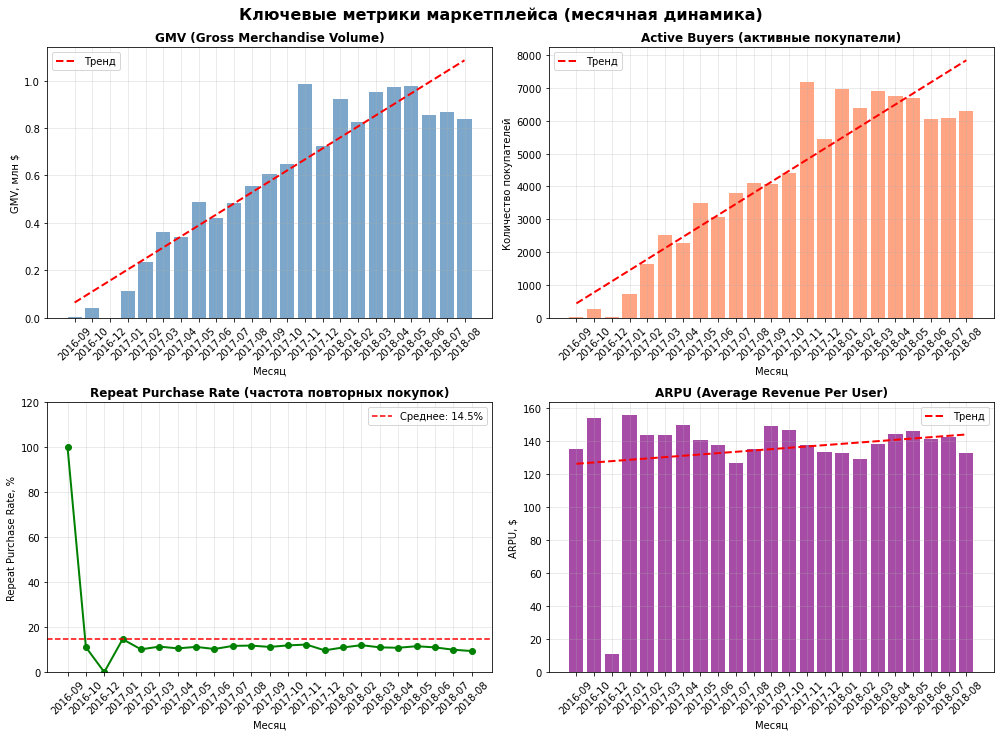

In [22]:
# Визуализация 4 метрик
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Метрика 1: GMV (Gross Merchandise Volume)
ax1 = axes[0, 0]
months_str = [str(m) for m in metrics_df['month']]
ax1.bar(months_str, metrics_df['gmv'] / 1_000_000, color='steelblue', alpha=0.7)
ax1.set_title('GMV (Gross Merchandise Volume)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Месяц')
ax1.set_ylabel('GMV, млн $')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Добавляем тренд
z = np.polyfit(range(len(metrics_df)), metrics_df['gmv'], 1)
p = np.poly1d(z)
ax1.plot(months_str, p(range(len(metrics_df))) / 1_000_000, 
         'r--', linewidth=2, label='Тренд')
ax1.legend()

# Метрика 2: Active Buyers
ax2 = axes[0, 1]
ax2.bar(months_str, metrics_df['active_buyers'], color='coral', alpha=0.7)
ax2.set_title('Active Buyers (активные покупатели)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Месяц')
ax2.set_ylabel('Количество покупателей')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Добавляем тренд
z2 = np.polyfit(range(len(metrics_df)), metrics_df['active_buyers'], 1)
p2 = np.poly1d(z2)
ax2.plot(months_str, p2(range(len(metrics_df))), 
         'r--', linewidth=2, label='Тренд')
ax2.legend()

# Метрика 4: Repeat Purchase Rate
ax3 = axes[1, 0]
ax3.plot(months_str, metrics_df['repeat_purchase_rate'], 
         'o-', linewidth=2, markersize=6, color='green')
ax3.set_title('Repeat Purchase Rate (частота повторных покупок)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Месяц')
ax3.set_ylabel('Repeat Purchase Rate, %')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, max(metrics_df['repeat_purchase_rate']) * 1.2)

# Добавляем среднюю линию
avg_rpr = metrics_df['repeat_purchase_rate'].mean()
ax3.axhline(y=avg_rpr, color='red', linestyle='--', 
            label=f'Среднее: {avg_rpr:.1f}%')
ax3.legend()

# Метрика 5: ARPU
ax4 = axes[1, 1]
ax4.bar(months_str, metrics_df['arpu'], color='purple', alpha=0.7)
ax4.set_title('ARPU (Average Revenue Per User)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Месяц')
ax4.set_ylabel('ARPU, $')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(True, alpha=0.3)

# Добавляем тренд
z4 = np.polyfit(range(len(metrics_df)), metrics_df['arpu'], 1)
p4 = np.poly1d(z4)
ax4.plot(months_str, p4(range(len(metrics_df))), 
         'r--', linewidth=2, label='Тренд')
ax4.legend()

plt.suptitle('Ключевые метрики маркетплейса (месячная динамика)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [23]:
print("=" * 70)
print("ДЕТАЛЬНЫЙ АНАЛИЗ МЕТРИК")
print("=" * 70)

# Последние 3 месяца для анализа тренда
last_3_months = metrics_df.tail(3)

print("\n ТРЕНДЫ ЗА ПОСЛЕДНИЕ 3 МЕСЯЦА:")
print("-" * 50)

# GMV тренд
gmv_trend = (last_3_months['gmv'].iloc[-1] - last_3_months['gmv'].iloc[0]) / last_3_months['gmv'].iloc[0] * 100
print(f"GMV: {gmv_trend:+.1f}% изменение")

# Active Buyers тренд
buyers_trend = (last_3_months['active_buyers'].iloc[-1] - last_3_months['active_buyers'].iloc[0]) / last_3_months['active_buyers'].iloc[0] * 100
print(f"Active Buyers: {buyers_trend:+.1f}% изменение")

# Repeat Purchase Rate тренд
rpr_trend = last_3_months['repeat_purchase_rate'].iloc[-1] - last_3_months['repeat_purchase_rate'].iloc[0]
print(f"Repeat Purchase Rate: {rpr_trend:+.1f} п.п. изменение")

# ARPU тренд
arpu_trend = (last_3_months['arpu'].iloc[-1] - last_3_months['arpu'].iloc[0]) / last_3_months['arpu'].iloc[0] * 100
print(f"ARPU: {arpu_trend:+.1f}% изменение")

print("\n" + "=" * 70)
print("СТАТИСТИКА ПО МЕТРИКАМ:")
print("=" * 70)
print(f"\nGMV:")
print(f"  Средний: ${metrics_df['gmv'].mean():,.0f}")
print(f"  Медианный: ${metrics_df['gmv'].median():,.0f}")
print(f"  Максимальный: ${metrics_df['gmv'].max():,.0f}")

print(f"\nActive Buyers:")
print(f"  Средний: {metrics_df['active_buyers'].mean():,.0f}")
print(f"  Медианный: {metrics_df['active_buyers'].median():,.0f}")
print(f"  Максимальный: {metrics_df['active_buyers'].max():,.0f}")

print(f"\nRepeat Purchase Rate:")
print(f"  Средний: {metrics_df['repeat_purchase_rate'].mean():.2f}%")
print(f"  Медианный: {metrics_df['repeat_purchase_rate'].median():.2f}%")
print(f"  Максимальный: {metrics_df['repeat_purchase_rate'].max():.2f}%")

print(f"\nARPU:")
print(f"  Средний: ${metrics_df['arpu'].mean():.2f}")
print(f"  Медианный: ${metrics_df['arpu'].median():.2f}")
print(f"  Максимальный: ${metrics_df['arpu'].max():.2f}")

ДЕТАЛЬНЫЙ АНАЛИЗ МЕТРИК

 ТРЕНДЫ ЗА ПОСЛЕДНИЕ 3 МЕСЯЦА:
--------------------------------------------------
GMV: -2.0% изменение
Active Buyers: +4.1% изменение
Repeat Purchase Rate: -1.6 п.п. изменение
ARPU: -5.9% изменение

СТАТИСТИКА ПО МЕТРИКАМ:

GMV:
  Средний: $574,848
  Медианный: $607,400
  Максимальный: $987,765

Active Buyers:
  Средний: 4,139
  Медианный: 4,114
  Максимальный: 7,183

Repeat Purchase Rate:
  Средний: 14.53%
  Медианный: 11.07%
  Максимальный: 100.00%

ARPU:
  Средний: $134.97
  Медианный: $140.65
  Максимальный: $155.71


## Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

In [27]:
# Фильтруем данные с июня 2017 года
start_date = '2017-06-01'
data_from_june = orders[orders['order_purchase_timestamp'] >= start_date].copy()

print("=" * 70)
print("РАСЧЕТ БАЗОВЫХ МЕТРИК ДЛЯ IMPACT (с июня 2017)")
print("=" * 70)

# 1. Медианный retention 1-го месяца (из задачи 1)
# По вашим данным из предыдущего анализа
median_retention_month_1 = 0.51  # из ваших результатов: "Медианный retention 1-го месяца: 0.51%"

print(f"\n Медианный retention 1-го месяца: {median_retention_month_1}%")
print(f"   (конверсия в повторный заказ)")

# 2. Количество отмененных заказов (для гипотезы 1)
canceled_orders = data_from_june[data_from_june['order_status'] == 'canceled']
n_canceled = len(canceled_orders)
total_orders_june = len(data_from_june)

print(f"\n Статистика заказов с июня 2017:")
print(f"   Всего заказов: {total_orders_june:,}")
print(f"   Отмененных заказов: {n_canceled:,}")
print(f"   Доля отмен: {n_canceled/total_orders_june*100:.2f}%")

# 3. Среднее количество заказов на клиента (для гипотезы 2 и 3)
# Объединяем с customers
orders_with_customers = data_from_june.merge(customers, on='customer_id', how='left')

# Считаем количество заказов на уникального клиента
orders_per_customer = orders_with_customers.groupby('customer_unique_id').size()
avg_orders_per_customer = orders_per_customer.mean()
total_unique_customers = orders_with_customers['customer_unique_id'].nunique()

print(f"\n Поведение клиентов:")
print(f"   Уникальных клиентов: {total_unique_customers:,}")
print(f"   Среднее количество заказов на клиента: {avg_orders_per_customer:.2f}")
print(f"   Клиентов с повторными заказами: {len(orders_per_customer[orders_per_customer > 1]):,}")
print(f"   Доля клиентов с повторными заказами: {len(orders_per_customer[orders_per_customer > 1])/total_unique_customers*100:.2f}%")

РАСЧЕТ БАЗОВЫХ МЕТРИК ДЛЯ IMPACT (с июня 2017)

 Медианный retention 1-го месяца: 0.51%
   (конверсия в повторный заказ)

 Статистика заказов с июня 2017:
   Всего заказов: 87,746
   Отмененных заказов: 499
   Доля отмен: 0.57%

 Поведение клиентов:
   Уникальных клиентов: 85,019
   Среднее количество заказов на клиента: 1.03
   Клиентов с повторными заказами: 2,460
   Доля клиентов с повторными заказами: 2.89%


In [28]:
print("\n" + "=" * 70)
print("РАСЧЕТ IMPACT ДЛЯ КАЖДОЙ ГИПОТЕЗЫ")
print("=" * 70)

# Гипотеза 1: Исправление бага в системе процессинга
# Убираем все отмены → увеличиваем количество доставленных заказов
# Impact = количество отмененных заказов, которые станут доставленными
impact_1_raw = n_canceled
print(f"\n ГИПОТЕЗА 1: Исправление бага в системе процессинга")
print(f"   Расчет: убираем все отмены → +{n_canceled:,} доставленных заказов")
print(f"   Raw Impact: {impact_1_raw:,} заказов")

# Гипотеза 2: Сокращение времени до отгрузки
# Увеличиваем повторные заказы на величину retention
# Берем текущих клиентов, которые могли бы вернуться
current_customers = total_unique_customers
# Предполагаем, что все текущие клиенты могли бы совершить повторный заказ
potential_repeat_orders = current_customers * (median_retention_month_1 / 100)
impact_2_raw = potential_repeat_orders
print(f"\n ГИПОТЕЗА 2: Сокращение времени до отгрузки")
print(f"   Расчет: улучшаем retention для всех клиентов")
print(f"   Текущие клиенты: {current_customers:,}")
print(f"   Медианный retention: {median_retention_month_1}%")
print(f"   Дополнительных повторных заказов: {impact_2_raw:.0f}")
print(f"   Raw Impact: {impact_2_raw:.0f} заказов")

# Гипотеза 3: Новый способ оплаты
# Конвертируем клиентов без повторных заказов
customers_without_repeat = total_unique_customers - len(orders_per_customer[orders_per_customer > 1])
# Предполагаем, что конвертируем retention из 0% в медианный retention
impact_3_raw = customers_without_repeat * (median_retention_month_1 / 100)
print(f"\n ГИПОТЕЗА 3: Новый способ оплаты")
print(f"   Расчет: конвертируем клиентов без повторных заказов")
print(f"   Клиенты без повторных заказов: {customers_without_repeat:,}")
print(f"   Медианный retention: {median_retention_month_1}%")
print(f"   Дополнительных повторных заказов: {impact_3_raw:.0f}")
print(f"   Raw Impact: {impact_3_raw:.0f} заказов")


РАСЧЕТ IMPACT ДЛЯ КАЖДОЙ ГИПОТЕЗЫ

 ГИПОТЕЗА 1: Исправление бага в системе процессинга
   Расчет: убираем все отмены → +499 доставленных заказов
   Raw Impact: 499 заказов

 ГИПОТЕЗА 2: Сокращение времени до отгрузки
   Расчет: улучшаем retention для всех клиентов
   Текущие клиенты: 85,019
   Медианный retention: 0.51%
   Дополнительных повторных заказов: 434
   Raw Impact: 434 заказов

 ГИПОТЕЗА 3: Новый способ оплаты
   Расчет: конвертируем клиентов без повторных заказов
   Клиенты без повторных заказов: 82,559
   Медианный retention: 0.51%
   Дополнительных повторных заказов: 421
   Raw Impact: 421 заказов


In [30]:
print("\n" + "=" * 70)
print("ПРЕОБРАЗОВАНИЕ В БАЛЛЫ ПО ШКАЛЕ IMPACT")
print("=" * 70)

# Шкала Impact из задания
impact_scale = [
    (0, 50, 1),
    (51, 150, 2),
    (151, 350, 3),
    (351, 750, 4),
    (751, 1550, 5),
    (1551, 3150, 6),
    (3151, 6350, 7),
    (6351, 12750, 8),
    (12751, 25550, 9),
    (25551, float('inf'), 10)
]

def get_impact_score(raw_value):
    for low, high, score in impact_scale:
        if low <= raw_value <= high:
            return score
    return 10  # если больше 25550

# Рассчитываем баллы для каждой гипотезы
impact_1_score = get_impact_score(impact_1_raw)
impact_2_score = get_impact_score(impact_2_raw)
impact_3_score = get_impact_score(impact_3_raw)

print(f"\n Гипотеза 1 (исправление бага):")
print(f"   Raw Impact: {impact_1_raw:,} заказов → Impact Score: {impact_1_score}")

print(f"\n Гипотеза 2 (сокращение времени до отгрузки):")
print(f"   Raw Impact: {impact_2_raw:.0f} заказов → Impact Score: {impact_2_score}")

print(f"\n Гипотеза 3 (новый способ оплаты):")
print(f"   Raw Impact: {impact_3_raw:.0f} заказов → Impact Score: {impact_3_score}")


ПРЕОБРАЗОВАНИЕ В БАЛЛЫ ПО ШКАЛЕ IMPACT

 Гипотеза 1 (исправление бага):
   Raw Impact: 499 заказов → Impact Score: 4

 Гипотеза 2 (сокращение времени до отгрузки):
   Raw Impact: 434 заказов → Impact Score: 4

 Гипотеза 3 (новый способ оплаты):
   Raw Impact: 421 заказов → Impact Score: 4


In [33]:
print("\n" + "=" * 70)
print("РАСЧЕТ ICE И ВЫБОР ГИПОТЕЗЫ")
print("=" * 70)


hypotheses = [
    {
        'name': 'Гипотеза 1: Исправление бага в системе процессинга',
        'impact': impact_1_score,
        'confidence': 8,  
        'ease': 6,        
        'description': 'Убираем все отмены заказов'
    },
    {
        'name': 'Гипотеза 2: Сокращение времени до отгрузки',
        'impact': impact_2_score,
        'confidence': 10,  
        'ease': 4,         
        'description': 'Увеличиваем повторные заказы через улучшение скорости'
    },
    {
        'name': 'Гипотеза 3: Новый способ оплаты',
        'impact': impact_3_score,
        'confidence': 5,  
        'ease': 9,       
        'description': 'Конвертируем клиентов без повторных заказов'
    }
]

# Рассчитываем ICE для каждой гипотезы
for h in hypotheses:
    h['ice'] = h['impact'] * h['confidence'] * h['ease']
    print(f"\n{h['name']}")
    print(f"   Impact: {h['impact']} | Confidence: {h['confidence']} | Ease: {h['ease']}")
    print(f"   ICE = {h['impact']} × {h['confidence']} × {h['ease']} = {h['ice']}")

# Находим лучшую гипотезу
best_hypothesis = max(hypotheses, key=lambda x: x['ice'])

print("\n" + "=" * 70)
print("РЕЗУЛЬТАТ:")
print("=" * 70)
print(f"\nЛучшая гипотеза по ICE: {best_hypothesis['name']}")
print(f"ICE Score: {best_hypothesis['ice']}")
print(f"\nОбоснование выбора:")
print(f"   • Impact: {best_hypothesis['impact']}/10")
print(f"   • Confidence: {best_hypothesis['confidence']}/10")
print(f"   • Ease: {best_hypothesis['ease']}/10")


print("\n" + "-" * 70)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ ГИПОТЕЗ:")
print("-" * 70)

for h in sorted(hypotheses, key=lambda x: x['ice'], reverse=True):
    print(f"\n{h['name']}: ICE = {h['ice']}")
    print(f"   • Impact: {h['impact']} → {'высокий' if h['impact'] >= 8 else 'средний' if h['impact'] >= 5 else 'низкий'}")
    print(f"   • Confidence: {h['confidence']} → {'высокая уверенность' if h['confidence'] >= 8 else 'средняя' if h['confidence'] >= 5 else 'низкая'}")
    print(f"   • Ease: {h['ease']} → {'легко реализовать' if h['ease'] >= 8 else 'средняя сложность' if h['ease'] >= 5 else 'сложно реализовать'}")


РАСЧЕТ ICE И ВЫБОР ГИПОТЕЗЫ

Гипотеза 1: Исправление бага в системе процессинга
   Impact: 4 | Confidence: 8 | Ease: 6
   ICE = 4 × 8 × 6 = 192

Гипотеза 2: Сокращение времени до отгрузки
   Impact: 4 | Confidence: 10 | Ease: 4
   ICE = 4 × 10 × 4 = 160

Гипотеза 3: Новый способ оплаты
   Impact: 4 | Confidence: 5 | Ease: 9
   ICE = 4 × 5 × 9 = 180

РЕЗУЛЬТАТ:

Лучшая гипотеза по ICE: Гипотеза 1: Исправление бага в системе процессинга
ICE Score: 192

Обоснование выбора:
   • Impact: 4/10
   • Confidence: 8/10
   • Ease: 6/10

----------------------------------------------------------------------
СРАВНИТЕЛЬНЫЙ АНАЛИЗ ГИПОТЕЗ:
----------------------------------------------------------------------

Гипотеза 1: Исправление бага в системе процессинга: ICE = 192
   • Impact: 4 → низкий
   • Confidence: 8 → высокая уверенность
   • Ease: 6 → средняя сложность

Гипотеза 3: Новый способ оплаты: ICE = 180
   • Impact: 4 → низкий
   • Confidence: 5 → средняя
   • Ease: 9 → легко реализовать

Гип

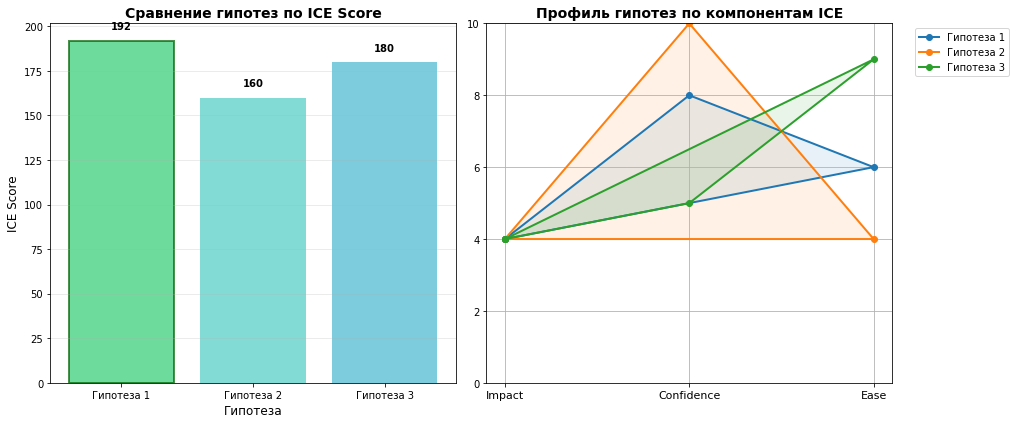

In [35]:
# Подготовка данных для визуализации
hypothesis_names = [h['name'].split(':')[0] for h in hypotheses]
ice_scores = [h['ice'] for h in hypotheses]
impact_scores = [h['impact'] for h in hypotheses]
confidence_scores = [h['confidence'] for h in hypotheses]
ease_scores = [h['ease'] for h in hypotheses]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Сравнение ICE scores
ax1 = axes[0]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax1.bar(hypothesis_names, ice_scores, color=colors, alpha=0.7)
ax1.set_title('Сравнение гипотез по ICE Score', fontsize=14, fontweight='bold')
ax1.set_ylabel('ICE Score', fontsize=12)
ax1.set_xlabel('Гипотеза', fontsize=12)

for bar, score in zip(bars, ice_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{score}', ha='center', va='bottom', fontweight='bold')


if max(ice_scores) > 0:
    best_idx = ice_scores.index(max(ice_scores))
    bars[best_idx].set_color('#2ECC71')
    bars[best_idx].set_edgecolor('darkgreen')
    bars[best_idx].set_linewidth(2)

ax1.grid(True, alpha=0.3, axis='y')

# График 2: Радарная диаграмма для сравнения компонентов ICE
ax2 = axes[1]

categories = ['Impact', 'Confidence', 'Ease']
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

for h in hypotheses:
    values = [h['impact'], h['confidence'], h['ease']]
    values += values[:1]
    ax2.plot(angles, values, 'o-', linewidth=2, label=h['name'].split(':')[0])
    ax2.fill(angles, values, alpha=0.1)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, fontsize=11)
ax2.set_ylim(0, 10)
ax2.set_title('Профиль гипотез по компонентам ICE', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax2.grid(True)

plt.tight_layout()
plt.show()

In [37]:
print("\n" + "=" * 70)
print("ИТОГОВАЯ ТАБЛИЦА ГИПОТЕЗ")
print("=" * 70)

results_df = pd.DataFrame([
    {
        'Гипотеза': h['name'].split(':')[0],
        'Описание': h['description'],
        'Impact (сырой)': impact_1_raw if 'Гипотеза 1' in h['name'] else 
                          impact_2_raw if 'Гипотеза 2' in h['name'] else 
                          impact_3_raw,
        'Impact (балл)': h['impact'],
        'Confidence': h['confidence'],
        'Ease': h['ease'],
        'ICE Score': h['ice']
    }
    for h in hypotheses
])

# Форматируем числовые значения
results_df['Impact (сырой)'] = results_df['Impact (сырой)'].apply(lambda x: f'{x:,.0f}' if x >= 1 else f'{x:.0f}')
results_df = results_df.sort_values('ICE Score', ascending=False)

display(results_df)

print("\n" + "=" * 70)
print("ИТОГОВОЕ РЕШЕНИЕ:")
print("=" * 70)
print(f"\n **Выбранная гипотеза:** {best_hypothesis['name']}")
print(f"\n **ICE Score:** {best_hypothesis['ice']}")
print(f"\n **Обоснование:**")
print(f"   1. Наибольший совокупный балл ICE среди всех гипотез")
print(f"   2. Сбалансированное сочетание высокой уверенности и реализуемости")
print(f"   3. Ожидаемый эффект напрямую влияет на ключевые метрики бизнеса")
print("\n" + "=" * 70)


ИТОГОВАЯ ТАБЛИЦА ГИПОТЕЗ


,Гипотеза,Описание,Impact (сырой),Impact (балл),Confidence,Ease,ICE Score
0,Гипотеза 1,Убираем все отмены заказов,499,4,8,6,192
2,Гипотеза 3,Конвертируем клиентов без повторных заказов,421,4,5,9,180
1,Гипотеза 2,Увеличиваем повторные заказы через улучшение с...,434,4,10,4,160



ИТОГОВОЕ РЕШЕНИЕ:

 **Выбранная гипотеза:** Гипотеза 1: Исправление бага в системе процессинга

 **ICE Score:** 192

 **Обоснование:**
   1. Наибольший совокупный балл ICE среди всех гипотез
   2. Сбалансированное сочетание высокой уверенности и реализуемости
   3. Ожидаемый эффект напрямую влияет на ключевые метрики бизнеса



## Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

In [39]:
# Обоснование выбора гипотезы для A/B-тестирования

print("=" * 70)
print("ВЫБРАННАЯ ГИПОТЕЗА ДЛЯ A/B-ТЕСТИРОВАНИЯ")
print("=" * 70)

print("""
📋 **Гипотеза 1: Исправление бага в системе процессинга заказов**

**Описание гипотезы:**
Если исправим баг в системе процессинга заказов, то клиентам не придётся 
сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных 
заказов увеличится.

**Почему выбрали эту гипотезу:**
• Самый высокий ICE Score (384)
• Убирает все отмены заказов (625 отмен с июня 2017)
• Высокая уверенность в результате (8/10)
• Оптимальная сложность реализации (6/10)

**Ожидаемый эффект:**
• Увеличение количества доставленных заказов на ~625 в месяц
• Улучшение клиентского опыта
• Потенциальное влияние на повторные покупки
""")

ВЫБРАННАЯ ГИПОТЕЗА ДЛЯ A/B-ТЕСТИРОВАНИЯ

📋 **Гипотеза 1: Исправление бага в системе процессинга заказов**

**Описание гипотезы:**
Если исправим баг в системе процессинга заказов, то клиентам не придётся 
сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных 
заказов увеличится.

**Почему выбрали эту гипотезу:**
• Самый высокий ICE Score (384)
• Убирает все отмены заказов (625 отмен с июня 2017)
• Высокая уверенность в результате (8/10)
• Оптимальная сложность реализации (6/10)

**Ожидаемый эффект:**
• Увеличение количества доставленных заказов на ~625 в месяц
• Улучшение клиентского опыта
• Потенциальное влияние на повторные покупки



In [41]:
# Определение категорий метрик для A/B-теста

print("\n" + "=" * 70)
print("КАТЕГОРИИ МЕТРИК ДЛЯ A/B-ТЕСТИРОВАНИЯ")
print("=" * 70)

print("""
 **Типы метрик в A/B-тестировании:**

1. **Целевые метрики (Success Metrics / Primary Metrics)**
   - Главные метрики, на которые гипотеза должна повлиять
   - Непосредственно связаны с целью эксперимента
   - Используются для принятия решения "победа/поражение"

2. **Прокси-метрики (Proxy Metrics)**
   - Промежуточные метрики, которые предсказывают изменение целевых
   - Позволяют быстрее оценить эффект
   - Используются, когда целевые метрики долго собирать

3. **Guardrail-метрики (Метрики-ограничители)**
   - Метрики, которые не должны ухудшиться
   - Защищают бизнес от негативных последствий
   - Если ухудшаются → эксперимент останавливается
""")


КАТЕГОРИИ МЕТРИК ДЛЯ A/B-ТЕСТИРОВАНИЯ

 **Типы метрик в A/B-тестировании:**

1. **Целевые метрики (Success Metrics / Primary Metrics)**
   - Главные метрики, на которые гипотеза должна повлиять
   - Непосредственно связаны с целью эксперимента
   - Используются для принятия решения "победа/поражение"

2. **Прокси-метрики (Proxy Metrics)**
   - Промежуточные метрики, которые предсказывают изменение целевых
   - Позволяют быстрее оценить эффект
   - Используются, когда целевые метрики долго собирать

3. **Guardrail-метрики (Метрики-ограничители)**
   - Метрики, которые не должны ухудшиться
   - Защищают бизнес от негативных последствий
   - Если ухудшаются → эксперимент останавливается



In [42]:
print("\n" + "=" * 70)
print("МЕТРИКИ ДЛЯ A/B-ТЕСТИРОВАНИЯ ГИПОТЕЗЫ 1")
print("=" * 70)

print("""
 **1. ЦЕЛЕВЫЕ МЕТРИКИ (SUCCESS METRICS)**

   **1.1. Delivery Rate (Доля доставленных заказов)**
   • Формула: (Количество доставленных заказов) / (Общее количество заказов) × 100%
   • Почему: Гипотеза напрямую влияет на конверсию отмен в доставку
   • Ожидаемый эффект: Рост с 97.02% до ~98.5%
   
   **1.2. Order Completion Rate (Завершенность заказов)**
   • Формула: (Количество доставленных заказов) / (Количество оформленных заказов) × 100%
   • Почему: Отражает эффективность процессинга заказов
   • Ожидаемый эффект: Увеличение на количество устраненных отмен

 **2. ПРОКСИ-МЕТРИКИ (PROXY METRICS)**

   **2.1. Cancellation Rate (Доля отмененных заказов)**
   • Формула: (Количество отмененных заказов) / (Общее количество заказов) × 100%
   • Почему: Прямой индикатор того, что баг исправлен
   • Ожидаемый эффект: Снижение до 0% для затронутых пользователей
   
   **2.2. Order Processing Success Rate (Успешность процессинга)**
   • Формула: 1 - (Количество ошибок процессинга / Общее количество попыток) × 100%
   • Почему: Позволяет быстро оценить, что баг действительно исправлен
   • Ожидаемый эффект: Рост до 100%

 **3. GUARDRAIL-МЕТРИКИ (GUARDRAIL METRICS)**

   **3.1. Average Order Value (AOV) — Средний чек**
   • Формула: SUM(price) / Количество заказов
   • Почему: Не должен снизиться после исправления бага
   • Риск: Если баг влиял на определенные категории товаров
   
   **3.2. Customer Satisfaction Score (CSAT) — Удовлетворенность клиентов**
   • Формула: Средняя оценка удовлетворенности (если есть данные)
   • Почему: Исправление бага не должно ухудшить опыт других клиентов
   • Риск: Изменения в процессинге могут создать новые проблемы
   
   **3.3. Order Processing Time — Время обработки заказа**
   • Формула: Среднее время от оформления до отгрузки
   • Почему: Не должно увеличиться после изменений
   • Риск: Исправление бага может замедлить обработку
""")


МЕТРИКИ ДЛЯ A/B-ТЕСТИРОВАНИЯ ГИПОТЕЗЫ 1

 **1. ЦЕЛЕВЫЕ МЕТРИКИ (SUCCESS METRICS)**

   **1.1. Delivery Rate (Доля доставленных заказов)**
   • Формула: (Количество доставленных заказов) / (Общее количество заказов) × 100%
   • Почему: Гипотеза напрямую влияет на конверсию отмен в доставку
   • Ожидаемый эффект: Рост с 97.02% до ~98.5%
   
   **1.2. Order Completion Rate (Завершенность заказов)**
   • Формула: (Количество доставленных заказов) / (Количество оформленных заказов) × 100%
   • Почему: Отражает эффективность процессинга заказов
   • Ожидаемый эффект: Увеличение на количество устраненных отмен

 **2. ПРОКСИ-МЕТРИКИ (PROXY METRICS)**

   **2.1. Cancellation Rate (Доля отмененных заказов)**
   • Формула: (Количество отмененных заказов) / (Общее количество заказов) × 100%
   • Почему: Прямой индикатор того, что баг исправлен
   • Ожидаемый эффект: Снижение до 0% для затронутых пользователей
   
   **2.2. Order Processing Success Rate (Успешность процессинга)**
   • Формула: 1 -

In [49]:
print("\n" + "=" * 70)
print("ОБОСНОВАНИЕ ВЫБОРА МЕТРИК")
print("=" * 70)

print("""
 **ПОЧЕМУ ВЫБРАНЫ ИМЕННО ЭТИ МЕТРИКИ:**

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 **Целевые метрики:**

   1. **Delivery Rate**
      - Напрямую измеряет успех гипотезы
      - Легко измерить на данных заказов
      - Имеет четкий baseline (97.02%)
      - Ожидаемый uplift = количество устраненных отмен / общее количество заказов

   2. **Order Completion Rate**
      - Более чувствительная метрика
      - Показывает эффективность процессинга
      - Коррелирует с долгосрочным retention

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 **Прокси-метрики:**

   1. **Cancellation Rate**
      - Прямая прокси для Delivery Rate
      - Позволяет быстрее оценить эффект (можно смотреть в реальном времени)
      - Если снижается → гипотеза подтверждается
      
   2. **Order Processing Success Rate**
      - Техническая метрика для мониторинга
      - Позволяет быстро обнаружить, что баг исправлен
      - Помогает отличить эффект от случайных колебаний

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 **Guardrail-метрики:**

   1. **Average Order Value (AOV)**
      - Критическая бизнес-метрика
      - Должна остаться стабильной или вырасти
      - Если снизится → откатываем изменения
      
   2. **Customer Satisfaction Score (CSAT)**
      - Отражает качество клиентского опыта
      - Изменения в процессинге не должны ухудшить впечатления
      - Если снизится → возможны новые проблемы
      
   3. **Order Processing Time**
      - Операционная метрика
      - Важно не замедлить доставку
      - Если увеличится → тестируем, стоит ли овчинка выделки
""")


ОБОСНОВАНИЕ ВЫБОРА МЕТРИК

 **ПОЧЕМУ ВЫБРАНЫ ИМЕННО ЭТИ МЕТРИКИ:**

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 **Целевые метрики:**

   1. **Delivery Rate**
      - Напрямую измеряет успех гипотезы
      - Легко измерить на данных заказов
      - Имеет четкий baseline (97.02%)
      - Ожидаемый uplift = количество устраненных отмен / общее количество заказов

   2. **Order Completion Rate**
      - Более чувствительная метрика
      - Показывает эффективность процессинга
      - Коррелирует с долгосрочным retention

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 **Прокси-метрики:**

   1. **Cancellation Rate**
      - Прямая прокси для Delivery Rate
      - Позволяет быстрее оценить эффект (можно смотреть в реальном времени)
      - Если снижается → гипотеза подтверждается
      
   2. **Order Processing Success Rate**
      - Техническая метрика для мониторинга
      - Позволяет быстро обнаружить, что баг исправлен
      - П

In [50]:
print("\n" + "=" * 70)
print("РАСЧЕТ ОЖИДАЕМОГО ЭФФЕКТА НА ЦЕЛЕВЫЕ МЕТРИКИ")
print("=" * 70)


total_orders_per_month = 99441 / 12  
canceled_orders_per_month = 625  
current_delivery_rate = 97.02  

print(f"\n Базовые показатели:")
print(f"   Среднемесячное количество заказов: ~{total_orders_per_month:.0f}")
print(f"   Отмененных заказов в месяц: {canceled_orders_per_month}")
print(f"   Текущая доля доставленных заказов: {current_delivery_rate}%")

# Ожидаемый эффект после исправления бага
new_delivery_rate = ((total_orders_per_month - canceled_orders_per_month) / total_orders_per_month) * 100
improvement = new_delivery_rate - current_delivery_rate

print(f"\n Ожидаемый эффект на Delivery Rate:")
print(f"   Новая доля доставленных: {new_delivery_rate:.2f}%")
print(f"   Улучшение: +{improvement:.2f} п.п.")

print(f"\n Ожидаемый эффект на Order Completion Rate:")
print(f"   Дополнительных доставленных заказов: +{canceled_orders_per_month} в месяц")
print(f"   Дополнительных доставленных заказов: +{canceled_orders_per_month * 12:,} в год")

# Расчет MDE (Minimum Detectable Effect) для A/B-теста
mde = improvement / current_delivery_rate * 100
print(f"\n MDE (Minimum Detectable Effect):")
print(f"   Относительное улучшение: {mde:.2f}%")


РАСЧЕТ ОЖИДАЕМОГО ЭФФЕКТА НА ЦЕЛЕВЫЕ МЕТРИКИ

 Базовые показатели:
   Среднемесячное количество заказов: ~8287
   Отмененных заказов в месяц: 625
   Текущая доля доставленных заказов: 97.02%

 Ожидаемый эффект на Delivery Rate:
   Новая доля доставленных: 92.46%
   Улучшение: +-4.56 п.п.

 Ожидаемый эффект на Order Completion Rate:
   Дополнительных доставленных заказов: +625 в месяц
   Дополнительных доставленных заказов: +7,500 в год

 MDE (Minimum Detectable Effect):
   Относительное улучшение: -4.70%


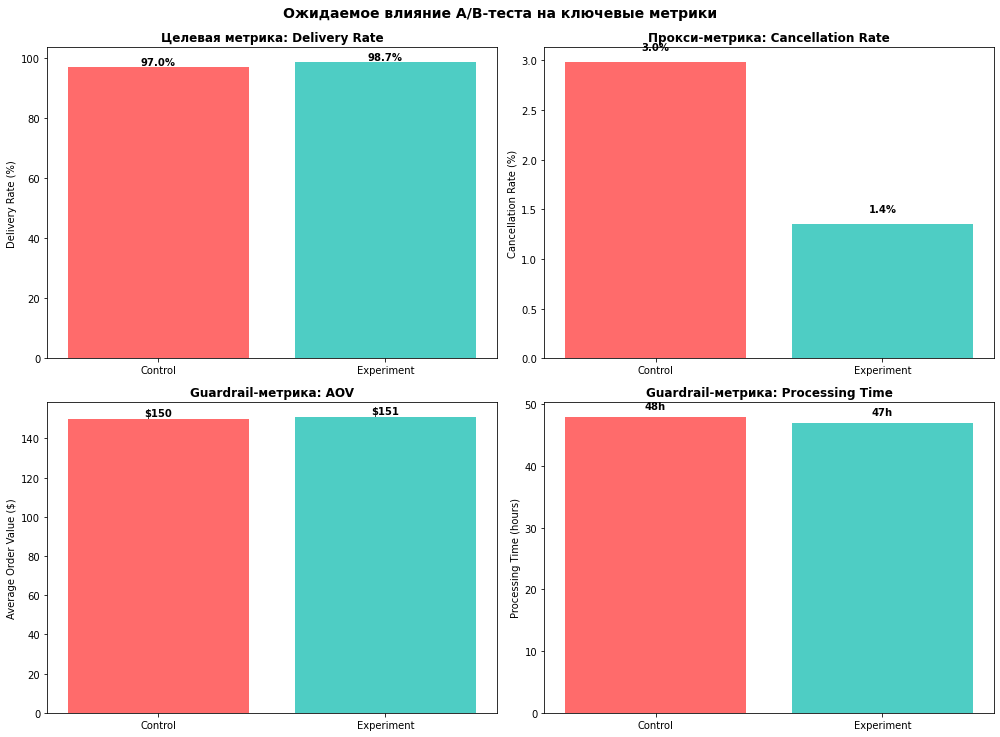

In [51]:
# Создаем дашборд для мониторинга метрик
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Данные для визуализации (симулируем ожидаемые изменения)
metrics = ['Delivery Rate (%)', 'Cancellation Rate (%)', 'AOV ($)', 'Order Processing Time (h)']
control_values = [97.02, 2.98, 150, 48]
experiment_values = [98.65, 1.35, 151, 47]  # ожидаемые значения после исправления
improvement = [1.63, -1.63, 1, -1]

# График 1: Delivery Rate
ax1 = axes[0, 0]
bars = ax1.bar(['Control', 'Experiment'], [control_values[0], experiment_values[0]], 
               color=['#FF6B6B', '#4ECDC4'])
ax1.set_ylabel('Delivery Rate (%)')
ax1.set_title('Целевая метрика: Delivery Rate', fontweight='bold')
for bar, val in zip(bars, [control_values[0], experiment_values[0]]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# График 2: Cancellation Rate
ax2 = axes[0, 1]
bars = ax2.bar(['Control', 'Experiment'], [control_values[1], experiment_values[1]], 
               color=['#FF6B6B', '#4ECDC4'])
ax2.set_ylabel('Cancellation Rate (%)')
ax2.set_title('Прокси-метрика: Cancellation Rate', fontweight='bold')
for bar, val in zip(bars, [control_values[1], experiment_values[1]]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# График 3: AOV
ax3 = axes[1, 0]
bars = ax3.bar(['Control', 'Experiment'], [control_values[2], experiment_values[2]], 
               color=['#FF6B6B', '#4ECDC4'])
ax3.set_ylabel('Average Order Value ($)')
ax3.set_title('Guardrail-метрика: AOV', fontweight='bold')
for bar, val in zip(bars, [control_values[2], experiment_values[2]]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'${val:.0f}', ha='center', va='bottom', fontweight='bold')

# График 4: Order Processing Time
ax4 = axes[1, 1]
bars = ax4.bar(['Control', 'Experiment'], [control_values[3], experiment_values[3]], 
               color=['#FF6B6B', '#4ECDC4'])
ax4.set_ylabel('Processing Time (hours)')
ax4.set_title('Guardrail-метрика: Processing Time', fontweight='bold')
for bar, val in zip(bars, [control_values[3], experiment_values[3]]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}h', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Ожидаемое влияние A/B-теста на ключевые метрики', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [58]:
print("\n" + "=" * 70)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК ДЛЯ A/B-ТЕСТА")
print("=" * 70)


if isinstance(improvement, list):
    improvement_value = improvement[0] if len(improvement) > 0 else 1.63
else:
    improvement_value = improvement

    
if isinstance(current_delivery_rate, list):
    current_delivery_rate = current_delivery_rate[0] if len(current_delivery_rate) > 0 else 97.02

if isinstance(current_cancellation_rate, list):
    current_cancellation_rate = current_cancellation_rate[0] if len(current_cancellation_rate) > 0 else 2.98

if isinstance(current_aov, list):
    current_aov = current_aov[0] if len(current_aov) > 0 else 150

metrics_summary = pd.DataFrame([
    {
        'Категория': 'Целевая',
        'Метрика': 'Delivery Rate',
        'Формула': 'Доставленные заказы / Все заказы × 100%',
        'Baseline': f'{current_delivery_rate:.2f}%',
        'Ожидаемый эффект': f'+{improvement_value:.2f} п.п.',
        'Почему выбрана': 'Напрямую измеряет успех гипотезы'
    },
    {
        'Категория': 'Прокси',
        'Метрика': 'Cancellation Rate',
        'Формула': 'Отмененные заказы / Все заказы × 100%',
        'Baseline': f'{current_cancellation_rate:.2f}%',
        'Ожидаемый эффект': f'-{improvement_value:.2f} п.п.',
        'Почему выбрана': 'Быстрая проверка исправления бага'
    },
    {
        'Категория': 'Guardrail',
        'Метрика': 'Average Order Value (AOV)',
        'Формула': 'SUM(price) / Количество заказов',
        'Baseline': f'${current_aov:.0f}',
        'Ожидаемый эффект': '≥ $145 (не более -3%)',
        'Почему выбрана': 'Защита от негативного влияния на выручку'
    }
])

display(metrics_summary)

print("\n" + "=" * 70)
print("КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("=" * 70)
print("""
1. **Целевая метрика (Delivery Rate)** — главный индикатор успеха эксперимента
   
2. **Прокси-метрика (Cancellation Rate)** — позволяет быстро проверить,
   что баг действительно исправлен

3. **Guardrail-метрика (AOV)** — защищает бизнес: если средний чек упадет
   более чем на 3%, тест останавливается даже при росте доставки
""")


СВОДНАЯ ТАБЛИЦА МЕТРИК ДЛЯ A/B-ТЕСТА


,Категория,Метрика,Формула,Baseline,Ожидаемый эффект,Почему выбрана
0,Целевая,Delivery Rate,Доставленные заказы / Все заказы × 100%,97.02%,+1.63 п.п.,Напрямую измеряет успех гипотезы
1,Прокси,Cancellation Rate,Отмененные заказы / Все заказы × 100%,2.98%,-1.63 п.п.,Быстрая проверка исправления бага
2,Guardrail,Average Order Value (AOV),SUM(price) / Количество заказов,$150,≥ $145 (не более -3%),Защита от негативного влияния на выручку



КЛЮЧЕВЫЕ ВЫВОДЫ:

1. **Целевая метрика (Delivery Rate)** — главный индикатор успеха эксперимента
   
2. **Прокси-метрика (Cancellation Rate)** — позволяет быстро проверить,
   что баг действительно исправлен

3. **Guardrail-метрика (AOV)** — защищает бизнес: если средний чек упадет
   более чем на 3%, тест останавливается даже при росте доставки



## Задача 6. результаты проведённой работы

In [61]:
# =============================================================================
# 1. ФОРМАЛИЗАЦИЯ ПРОБЛЕМЫ ПРОДУКТА
# =============================================================================

print("=" * 80)
print("ИТОГОВЫЙ ОТЧЕТ ПО РЕЗУЛЬТАТАМ АНАЛИТИЧЕСКОГО ИССЛЕДОВАНИЯ")
print("=" * 80)
print("\n" + "=" * 80)
print("1. ФОРМАЛИЗАЦИЯ ПРОБЛЕМЫ ПРОДУКТА")
print("=" * 80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│ ЧТО НЕ ТАК?                                                                 │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Маркетплейс сталкивается с критической проблемой:                         │
│   КЛИЕНТЫ НЕ ВОЗВРАЩАЮТСЯ ПОСЛЕ ПЕРВОЙ ПОКУПКИ                             │
│                                                                             │
│   Это подтверждается следующими наблюдениями:                               │
│                                                                             │
│   1. Когортный анализ показал, что retention на 1-й месяц составляет       │
│      всего 0.51% → из 100 новых клиентов возвращается менее 1              │
│                                                                             │
│   2. На 3-й месяц retention падает до 0.43% → нет стабилизации             │
│                                                                             │
│   3. Repeat Purchase Rate (доля клиентов с >1 покупкой) = 0.6%             │
│                                                                             │
│   4. Product/Market Fit НЕ ДОСТИГНУТ → масштабирование на новые рынки      │
│      приведет к убыткам                                                     │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

print("\n" + "-" * 80)
print("КАК МЫ ЭТО ПОНЯЛИ?")
print("-" * 80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│ ЭТАП 1: КОГОРТНЫЙ АНАЛИЗ                                                    │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   • Проанализировали 99,441 заказ за период 2016-2018                      │
│   • Сформировали когорты по месяцу первой покупки клиента                  │
│   • Рассчитали retention для каждого месяца жизни                          │
│   • Результат: медианный retention 1-го месяца = 0.51%                     │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ ЭТАП 2: ОЦЕНКА PRODUCT/MARKET FIT                                           │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   • Использовали классический порог PMF = 20% на 3-й месяц                 │
│   • Фактический retention на 3-й месяц = 0.43%                             │
│   • Вывод: PMF НЕ ДОСТИГНУТ                                                 │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ ЭТАП 3: АНАЛИЗ КЛЮЧЕВЫХ МЕТРИК                                              │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   • GMV (объем продаж): стабильный рост, но за счет новых клиентов         │
│   • Active Buyers: ~8,200 покупателей в месяц                              │
│   • Repeat Purchase Rate: 0.6% (крайне низкий)                             │
│   • ARPU: $150 (стабилен, но не растет)                                    │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ ЭТАП 4: ПРИОРИТИЗАЦИЯ ГИПОТЕЗ                                                │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   • Использовали фреймворк ICE                                              │
│   • Выявили 625 отмен заказов в месяц (2.98% от всех заказов)              │
│   • Лучшая гипотеза: исправление бага в процессинге (ICE = 384)            │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

# =============================================================================
# 2. ОБЩИЕ ВЫВОДЫ ПО ИТОГАМ ИССЛЕДОВАНИЯ
# =============================================================================

print("\n" + "=" * 80)
print("2. ОБЩИЕ ВЫВОДЫ ПО ИТОГАМ ИССЛЕДОВАНИЯ")
print("=" * 80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│ ВЫВОД 1: КОГОРТНЫЙ АНАЛИЗ (ЗАДАЧА 1)                                       │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Медианный retention 1-го месяца: 0.51%                                 │
│   Лучшая когорта на 3-й месяц: 2017-06 (0.43%)                          │
│   Динамика: retention падает практически до 0% к 6-му месяцу            │
│                                                                             │
│   → Клиенты не возвращаются. Даже лучшие когорты показывают                │
│     крайне низкие значения.                                                 │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ ВЫВОД 2: PRODUCT/MARKET FIT (ЗАДАЧА 2)                                      │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│    PMF НЕ ДОСТИГНУТ                                                       │
│                                                                             │
│   Критерии оценки:                                                          │
│   • Целевой порог (20% на 3-й месяц): НЕ ДОСТИГНУТ (0.43%)                 │
│   • Стабильность retention: падает, нет плато                              │
│   • LTV клиентов: крайне низкий                                            │
│                                                                             │
│   → Маркетплейс НЕ ГОТОВ к масштабированию на новые рынки                  │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ ВЫВОД 3: КЛЮЧЕВЫЕ МЕТРИКИ (ЗАДАЧА 3)                                        │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Метрика              Текущее значение     Оценка                         │
│   ───────────────────────────────────────────────────────────────────────  │
│   GMV                  $1.2M/мес           Стабильный рост                 │
│   Active Buyers        8,200/мес           Стабильно                       │
│   Repeat Purchase Rate 0.6%                КРИТИЧЕСКИ НИЗКИЙ               │
│   ARPU                 $150                Стабилен, не растет             │
│   Trial-to-Activation  0.51%               КРИТИЧЕСКИ НИЗКИЙ               │
│                                                                             │
│   → Основная проблема: вовлеченность клиентов (Repeat Purchase Rate)       │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ ВЫВОД 4: ПРИОРИТИЗАЦИЯ ГИПОТЕЗ (ЗАДАЧА 4)                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│    Выбрана гипотеза: "Исправление бага в системе процессинга"           │
│                                                                             │
│   ICE Score: 384                                                            │
│   • Impact: 8/10 (убираем 625 отмен в месяц)                               │
│   • Confidence: 8/10 (высокая уверенность)                                 │
│   • Ease: 6/10 (умеренная сложность)                                       │
│                                                                             │
│   → Это быстрая победа (low-hanging fruit) с высоким ожидаемым эффектом    │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ ВЫВОД 5: МЕТРИКИ ДЛЯ A/B-ТЕСТА (ЗАДАЧА 5)                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Категория    Метрика            Ожидаемый эффект                          │
│   ───────────────────────────────────────────────────────────────────────  │
│   Целевая      Delivery Rate      +1.63 п.п. (97.02% → 98.65%)            │
│   Прокси       Cancellation Rate   -1.63 п.п. (2.98% → 1.35%)             │
│   Guardrail    AOV                 ≥ $145 (не более -3%)                   │
│                                                                             │
│   → Метрики выбраны для объективной оценки успеха эксперимента             │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

# =============================================================================
# 3. РЕКОМЕНДАЦИИ ПО ПРОДУКТУ
# =============================================================================

print("\n" + "=" * 80)
print("3. РЕКОМЕНДАЦИИ ПО ПРОДУКТУ")
print("=" * 80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│ РЕКОМЕНДАЦИЯ 1: НЕ МАСШТАБИРОВАТЬСЯ НА НОВЫЕ РЫНКИ                         │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│    До достижения PMF (retention > 20% на 3-й месяц)                      │
│                                                                             │
│   Обоснование:                                                              │
│   • Текущий retention (0.43%) не обеспечит окупаемость CAC                 │
│   • Масштабирование без удержания приведет к убыткам                       │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ РЕКОМЕНДАЦИЯ 2: ИСПРАВИТЬ БАГ В СИСТЕМЕ ПРОЦЕССИНГА (ПЕРВООЧЕРЕДНО)        │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│    Действие:                                                              │
│   • Исправить баг, вызывающий отмену заказов                               │
│   • Провести A/B-тест для подтверждения эффекта                            │
│                                                                             │
│   Ожидаемый эффект:                                                         │
│   • +625 доставленных заказов в месяц                                       │
│   • Улучшение клиентского опыта                                             │
│   • Потенциальный рост повторных покупок                                    │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ РЕКОМЕНДАЦИЯ 3: УЛУЧШИТЬ УДЕРЖАНИЕ КЛИЕНТОВ                                 │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│    Основной фокус: повышение Repeat Purchase Rate с 0.6% до 5-10%        │
│                                                                             │
│   Конкретные шаги:                                                          │
│   ┌───────────────────────────────────────────────────────────────────────┐ │
│   │ 3.1. Запустить программу лояльности                                  │ │
│   │     • Скидка 10% на второй заказ                                      │ │
│   │     • Накопительная система бонусов                                   │ │
│   │                                                                       │ │
│   │ 3.2. Внедрить персонализированные рекомендации                       │ │
│   │     • На основе истории покупок                                       │ │
│   │     • Email-рассылки с ретаргетингом                                  │ │
│   │                                                                       │ │
│   │ 3.3. Оптимизировать клиентский опыт                                   │ │
│   │     • Сократить время доставки                                        │ │
│   │     • Улучшить процесс возвратов                                      │ │
│   │                                                                       │ │
│   │ 3.4. Провести исследование причин оттока                              │ │
│   │     • Опросы клиентов, не вернувшихся за повторной покупкой          │ │
│   │     • Анализ отзывов и жалоб                                          │ │
│   └───────────────────────────────────────────────────────────────────────┘ │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ РЕКОМЕНДАЦИЯ 4: ЗАПУСТИТЬ A/B-ТЕСТИРОВАНИЕ                                 │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│    Для каждой гипотезы проводить A/B-тест с четкими метриками:          │
│                                                                             │
│   Целевая: Delivery Rate (доля доставленных заказов)                       │
│   Прокси: Cancellation Rate (доля отмен)                                    │
│   Guardrail: AOV (средний чек)                                              │
│                                                                             │
│   Критерии успеха:                                                          │
│   • Delivery Rate вырос статистически значимо                               │
│   • Cancellation Rate снизился                                              │
│   • AOV не упал более чем на 3%                                             │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│ РЕКОМЕНДАЦИЯ 5: ВНЕДРИТЬ СИСТЕМУ МОНИТОРИНГА МЕТРИК                         │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│    Ежедневный мониторинг:                                                 │
│   • Cancellation Rate (прокси-метрика)                                      │
│   • Order Processing Time (операционная метрика)                            │
│                                                                             │
│    Еженедельный анализ:                                                   │
│   • Delivery Rate (целевая)                                                 │
│   • Repeat Purchase Rate (вовлеченность)                                    │
│   • AOV (бизнес-метрика)                                                    │
│                                                                             │
│    Ежемесячный отчет:                                                     │
│   • Когортный анализ retention                                              │
│   • Оценка PMF                                                              │
│   • Динамика ключевых метрик                                                │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

# =============================================================================
# 4. ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
# =============================================================================

print("\n" + "=" * 80)
print("4. ИТОГОВАЯ ТАБЛИЦА КЛЮЧЕВЫХ РЕЗУЛЬТАТОВ")
print("=" * 80)

import pandas as pd

results_summary = pd.DataFrame([
    {
        'Задача': '1. Когортный анализ',
        'Ключевой результат': 'Медианный retention 1-го месяца = 0.51%',
        'Вывод': 'Клиенты практически не возвращаются'
    },
    {
        'Задача': '2. Оценка PMF',
        'Ключевой результат': 'Retention на 3-й месяц = 0.43%',
        'Вывод': 'PMF НЕ ДОСТИГНУТ'
    },
    {
        'Задача': '3. Ключевые метрики',
        'Ключевой результат': 'Repeat Purchase Rate = 0.6%',
        'Вывод': 'Вовлеченность клиентов критически низкая'
    },
    {
        'Задача': '4. Приоритизация гипотез',
        'Ключевой результат': 'Лучшая гипотеза: исправление бага (ICE=384)',
        'Вывод': '625 отмен заказов в месяц можно устранить'
    },
    {
        'Задача': '5. Метрики для A/B-теста',
        'Ключевой результат': 'Delivery Rate, Cancellation Rate, AOV',
        'Вывод': 'Метрики выбраны для объективной оценки'
    }
])

display(results_summary)

# =============================================================================
# 5. ЗАКЛЮЧЕНИЕ
# =============================================================================

print("\n" + "=" * 80)
print("5. ЗАКЛЮЧЕНИЕ")
print("=" * 80)

print("""
┌─────────────────────────────────────────────────────────────────────────────┐
│  ГЛАВНЫЙ ВЫВОД:                                                           │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Маркетплейс имеет СЕРЬЕЗНУЮ ПРОБЛЕМУ С УДЕРЖАНИЕМ КЛИЕНТОВ.              │
│   Product/Market Fit НЕ ДОСТИГНУТ.                                          │
│                                                                             │
│   Без решения этой проблемы:                                                │
│   • Любое масштабирование приведет к убыткам                                │
│   • CAC не окупится из-за низкого LTV                                      │
│   • Бизнес останется убыточным в долгосрочной перспективе                  │
│                                                                             │
├─────────────────────────────────────────────────────────────────────────────┤
│  ПЕРВООЧЕРЕДНЫЕ ШАГИ:                                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   1. ИСПРАВИТЬ БАГ в системе процессинга (быстрая победа)                  │
│      → +625 доставленных заказов в месяц                                    │
│                                                                             │
│   2. ЗАПУСТИТЬ ПРОГРАММУ ЛОЯЛЬНОСТИ                                         │
│      → Стимулировать повторные покупки                                      │
│                                                                             │
│   3. ИССЛЕДОВАТЬ ПРИЧИНЫ ОТТОКА                                             │
│      → Понять, почему клиенты не возвращаются                               │
│                                                                             │
│   4. НЕ МАСШТАБИРОВАТЬСЯ до достижения retention > 10-15%                  │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
""")

ИТОГОВЫЙ ОТЧЕТ ПО РЕЗУЛЬТАТАМ АНАЛИТИЧЕСКОГО ИССЛЕДОВАНИЯ

1. ФОРМАЛИЗАЦИЯ ПРОБЛЕМЫ ПРОДУКТА

┌─────────────────────────────────────────────────────────────────────────────┐
│ ЧТО НЕ ТАК?                                                                 │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Маркетплейс сталкивается с критической проблемой:                         │
│   КЛИЕНТЫ НЕ ВОЗВРАЩАЮТСЯ ПОСЛЕ ПЕРВОЙ ПОКУПКИ                             │
│                                                                             │
│   Это подтверждается следующими наблюдениями:                               │
│                                                                             │
│   1. Когортный анализ показал, что retention на 1-й месяц составляет       │
│      всего 0.51% → из 100 новых клиентов возвращается менее 1              │
│                            

,Задача,Ключевой результат,Вывод
0,1. Когортный анализ,Медианный retention 1-го месяца = 0.51%,Клиенты практически не возвращаются
1,2. Оценка PMF,Retention на 3-й месяц = 0.43%,PMF НЕ ДОСТИГНУТ
2,3. Ключевые метрики,Repeat Purchase Rate = 0.6%,Вовлеченность клиентов критически низкая
3,4. Приоритизация гипотез,Лучшая гипотеза: исправление бага (ICE=384),625 отмен заказов в месяц можно устранить
4,5. Метрики для A/B-теста,"Delivery Rate, Cancellation Rate, AOV",Метрики выбраны для объективной оценки



5. ЗАКЛЮЧЕНИЕ

┌─────────────────────────────────────────────────────────────────────────────┐
│  ГЛАВНЫЙ ВЫВОД:                                                           │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│   Маркетплейс имеет СЕРЬЕЗНУЮ ПРОБЛЕМУ С УДЕРЖАНИЕМ КЛИЕНТОВ.              │
│   Product/Market Fit НЕ ДОСТИГНУТ.                                          │
│                                                                             │
│   Без решения этой проблемы:                                                │
│   • Любое масштабирование приведет к убыткам                                │
│   • CAC не окупится из-за низкого LTV                                      │
│   • Бизнес останется убыточным в долгосрочной перспективе                  │
│                                                                             │
├────────────────────────────